### Model Evaluation 

In [17]:
## Libraries to be used 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
model_performance_data = pd.read_parquet('../Clarity/datas/modelpeformance.parquet')
model_performance_data.head(5)

,model,mae,rmse,r2
0,xgboost,0.004277,0.007299,0.751044
1,lstm,0.004711,0.007835,0.707312
2,rnn,0.004638,0.007727,0.715352
3,garch,0.006597,0.009764,0.554579


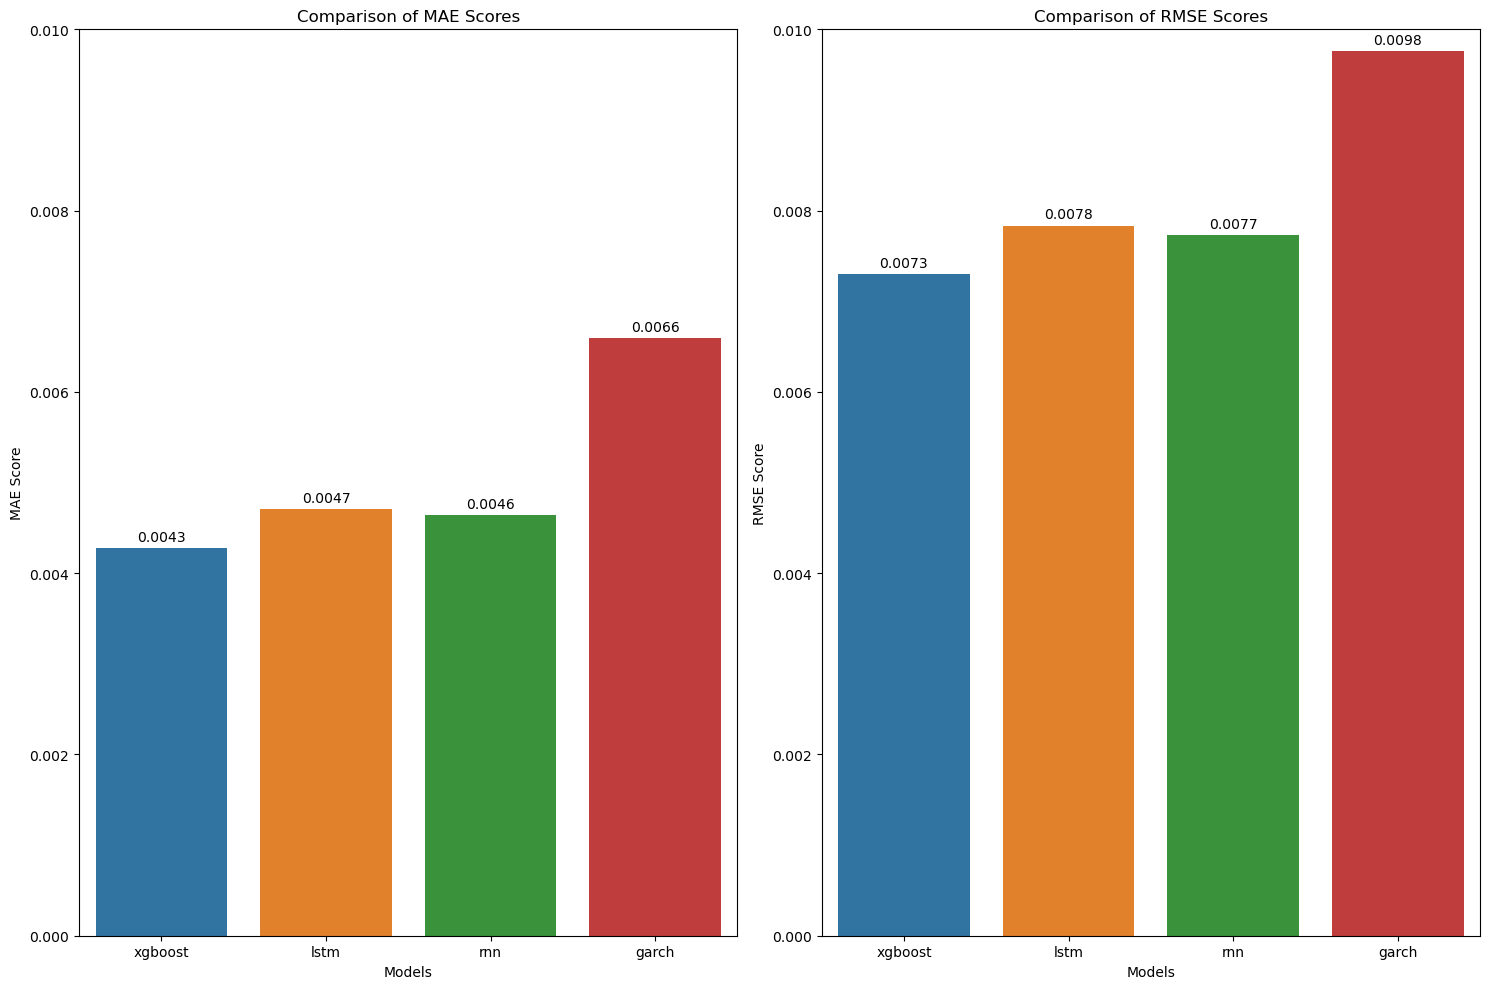

In [30]:
### Comparison of model's performance
fix, ax = plt.subplots(1,2,figsize = (15,10))
def plottingmetrics(x,y, data, title, xlabel, ylabel, ylim1, ylim2, axes):
    sns.barplot(x = x, y =y, data = data, hue = x, ax = axes)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    axes.set_ylim(ylim1, ylim2)
    for container in axes.containers:
        axes.bar_label(container, fmt="%.4f", padding=3)

plottingmetrics('model', 'mae', model_performance_data, 'Comparison of MAE Scores', 'Models', 'MAE Score', 0, 0.01, ax[0])
plottingmetrics('model', 'rmse', model_performance_data, 'Comparison of RMSE Scores', 'Models', 'RMSE Score', 0, 0.01, ax[1])
plt.tight_layout()
plt.savefig("../Clarity/modelperformance/maeandrmsescores.png")
plt.show()

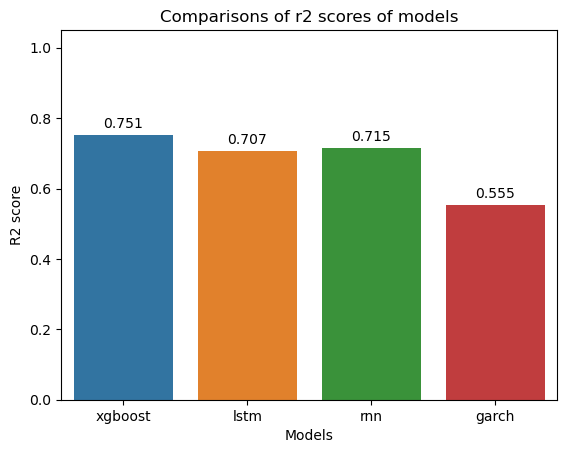

In [31]:
## R2 Score comparison between the models 
ax = sns.barplot(x='model', y='r2', data=model_performance_data, hue='model')

plt.xlabel("Models")
plt.ylabel("R2 score")
plt.ylim(0, 1.05)  # optional, gives labels some space
plt.title("Comparisons of r2 scores of models")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.savefig("../Clarity/modelperformance/r2scores.png")
plt.show()